In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import torch
from torch import nn
from tqdm import tqdm
from linformer import Linformer
from vit_pytorch.efficient import ViT
import torch.nn.functional as F
from torch.optim.lr_scheduler import StepLR
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split

In [2]:
import os
os.environ['TORCH_USE_CUDA_DSA']="1"
os.environ['CUDA_LAUNCH_BLOCKING']="1"

Load the data

In [3]:
connectome_data = pd.read_csv("./dataset/widsdatathon2025/TRAIN/TRAIN_FUNCTIONAL_CONNECTOME_MATRICES.csv")

qu_df = pd.read_excel("dataset/widsdatathon2025/TRAIN/TRAIN_QUANTITATIVE_METADATA.xlsx")
qu_df = qu_df.drop(index=qu_df.query('MRI_Track_Age_at_Scan >= 10 & MRI_Track_Age_at_Scan <= 10').index)
qu_df = qu_df.drop(index=qu_df[qu_df["MRI_Track_Age_at_Scan"].isna() == True].index)

connectome_data = connectome_data.drop(index=connectome_data[connectome_data["participant_id"].isin(qu_df["participant_id"].values) == False].index)


In [4]:
train_labels = pd.read_excel("./dataset/widsdatathon2025/TRAIN_NEW/TRAINING_SOLUTIONS.xlsx")

train_labels = train_labels.drop(index=connectome_data[connectome_data["participant_id"].isin(qu_df["participant_id"].values) == False].index)


In [5]:
# split the data into 4 splits
train_labels_adhd_male = train_labels[(train_labels["ADHD_Outcome"] == 1) & (train_labels["Sex_F"] == 0)]
train_labels_adhd_female = train_labels[(train_labels["ADHD_Outcome"] == 1) & (train_labels["Sex_F"] == 1)]
train_labels_no_adhd_male = train_labels[(train_labels["ADHD_Outcome"] == 0) & (train_labels["Sex_F"] == 0)]
train_labels_no_adhd_female = train_labels[(train_labels["ADHD_Outcome"] == 0) & (train_labels["Sex_F"] == 1)]

In [6]:
connectome_data_adhd_male = connectome_data[connectome_data['participant_id'].isin(train_labels_adhd_male['participant_id'])]
connectome_data_adhd_female = connectome_data[connectome_data['participant_id'].isin(train_labels_adhd_female['participant_id'])]
connectome_data_no_adhd_male = connectome_data[connectome_data['participant_id'].isin(train_labels_no_adhd_male['participant_id'])]
connectome_data_no_adhd_female = connectome_data[connectome_data['participant_id'].isin(train_labels_no_adhd_female['participant_id'])]

In [7]:
expected_num_regions = 200

# Build Adjacency matrices for 4 classes - ADHD (male), ADHD (female), No ADHD (male), No ADHD (female)

In [8]:
def construct_adjacency_matrix(connectome_data):
    connectivity_vectors = connectome_data.iloc[:, 1:].values
    num_patients = connectome_data.shape[0]

    upper_tri_indices = np.triu_indices(expected_num_regions, k=1)

    matrix_full = np.zeros((num_patients, expected_num_regions, expected_num_regions))

    for i in range(num_patients):
        matrix = np.zeros((expected_num_regions, expected_num_regions))
        matrix[upper_tri_indices] = connectivity_vectors[i]
        matrix += matrix.T
        np.fill_diagonal(matrix, 0)
        matrix_full[i] = matrix

    return matrix_full

In [9]:
print(connectome_data_adhd_male.shape)
print(connectome_data_adhd_male.iloc[0,0])
type(connectome_data_adhd_male)
cdam_t = connectome_data_adhd_male.drop(columns=["participant_id"]).transpose()

(406, 19901)
70z8Q2xdTXM3


In [10]:
# def make_ctme_image(row:pd.Series, imageDir = "CTME_images/"):
#   data =np.array([row[1:].to_numpy(dtype=np.float32)])
#   data = np.append(data, np.zeros(shape=(1,100), dtype=np.float32))
#   data = data.reshape((200,100))
#   # data = np.abs(data)
#   data = (data + 1.0)/2.
#   return data

def make_ctme_image(row:pd.Series, imageDir = "CTME_images/"):
  data = np.array([row[1:].to_numpy(dtype=np.float32)])
  data = (data+1.0)/2.0
  data = data*(data>=0.05).astype(np.float32)
  data = (data - data.min())/(data.max() - data.min())
  data = np.append(data, np.zeros(shape=(1,100), dtype=np.float32))
  data = data.reshape((200,100))

  return data


In [11]:
matrix_adhd_male = np.array([make_ctme_image(row) for index, row in connectome_data_adhd_male.iterrows()])

In [12]:
matrix_adhd_female = np.array([make_ctme_image(row) for index, row in connectome_data_adhd_female.iterrows()])

In [13]:
matrix_no_adhd_female = np.array([make_ctme_image(row) for index, row in connectome_data_no_adhd_female.iterrows()])

In [14]:
matrix_no_adhd_male = np.array([make_ctme_image(row) for index, row in connectome_data_no_adhd_male.iterrows()])

In [15]:
print(len(matrix_no_adhd_female)+len(matrix_adhd_female))
print(len(matrix_no_adhd_male)+len(matrix_adhd_male))

292
561


In [16]:
import matplotlib.pyplot as plt
def make_ctme_image(row:pd.Series, ind, imageDir = "CTME_images/"):

  data=row[1:]

  # data = np.array([row[1:].to_numpy(dtype=np.float32)])
  data = (data+1.0)/2.0
  # data = data*(data>=0.95).astype(np.float32)
  data = (data<=0.5).astype(np.float32)
  # data = (data - data.min())/(data.max() - data.min())
  data = 1.0 - data

  data = np.append(data, np.zeros(shape=(1,100), dtype=np.float32))

  data = data.reshape((200,100))


  plt.imsave(os.path.join(imageDir, f'{ind}.jpg'), data, cmap="Greys")


In [17]:


# i = 0
# for row in matrix_adhd_male:
#   make_ctme_image(row, i, "./CTME_images/ctme_adhd")
#   i+=1
# for row in matrix_adhd_female:
#   make_ctme_image(row, i, "./CTME_images/ctme_adhd")
#   i+=1

# i = 0
# for row in matrix_no_adhd_male:
#   make_ctme_image(row, i, "./CTME_images/ctme_no_adhd")
#   i+=1
# for row in matrix_no_adhd_female:
#   make_ctme_image(row, i, "./CTME_images/ctme_no_adhd")
#   i+=1

# i = 0
# for row in matrix_adhd_male:
#   make_ctme_image(row, i, "./CTME_images/male")
#   i+=1
# for row in matrix_no_adhd_male:
#   make_ctme_image(row, i, "./CTME_images/male")
#   i+=1

# i = 0
# for row in matrix_adhd_female:
#   make_ctme_image(row, i, "./CTME_images/female")
#   i+=1
# for row in matrix_no_adhd_female:
#   make_ctme_image(row, i, "./CTME_images/female")
#   i+=1


# os.system("ffmpeg -i ./CTME_images/female/%d.jpg ./female.gif -y")
# os.system("ffmpeg -i ./CTME_images/male/%d.jpg ./male.gif -y")
# os.system("ffmpeg -i ./CTME_images/ctme_adhd/%d.jpg ./adhd.gif -y")
# os.system("ffmpeg -i ./CTME_images/ctme_no_adhd/%d.jpg ./no_adhd.gif -y")

In [18]:
# matrix_adhd_male = construct_adjacency_matrix(connectome_data_adhd_male)
# print(type(matrix_adhd_male))
# matrix_adhd_female = construct_adjacency_matrix(connectome_data_adhd_female)
# matrix_no_adhd_male = construct_adjacency_matrix(connectome_data_no_adhd_male)
# matrix_no_adhd_female = construct_adjacency_matrix(connectome_data_no_adhd_female)

In [19]:
print(matrix_adhd_male.shape)
print(matrix_adhd_female.shape)
print(matrix_no_adhd_male.shape)
print(matrix_no_adhd_female.shape)

(406, 200, 100)
(174, 200, 100)
(155, 200, 100)
(118, 200, 100)


In [20]:
# sns.heatmap(matrix_adhd_female[0])

In [21]:
# combined_matrix_dataset = list(matrix_adhd_female) + list(matrix_adhd_male) + list(matrix_no_adhd_male) + list(matrix_no_adhd_female)

combined_matrix_dataset = list(matrix_adhd_female) + list(matrix_no_adhd_female) + list(matrix_adhd_male) + list(matrix_no_adhd_male)

combined_matrix_dataset = np.array(combined_matrix_dataset)

In [22]:
labels = np.array([1] * (406+174) + [0] * (155+118)).astype(np.float32)
# labels = np.array(labels).astype(np.float32)


In [23]:
print(combined_matrix_dataset.shape)
print(len(labels))

print(labels)

(853, 200, 100)
853
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 

Dataset Class

In [24]:
class ConnectomeMapDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        self.filelength = len(self.files)
        return self.filelength

    def __getitem__(self, idx):
        file = self.files[idx]
        file = file.reshape((1, file.shape[0], file.shape[1]))
        label = self.labels[idx]

        return file, label


In [25]:
train_list, test_list, train_labels, test_labels = train_test_split(combined_matrix_dataset, labels, test_size=0.2, random_state=42, shuffle=True)


In [26]:
train_data = ConnectomeMapDataset(train_list, train_labels)
test_data = ConnectomeMapDataset(test_list, test_labels)

In [27]:
# Training settings
batch_size = 64
epochs = 100
lr = 3e-5
gamma = 0.7
seed = 42

In [28]:
train_loader = DataLoader(dataset = train_data, batch_size=batch_size, shuffle=True )
test_loader = DataLoader(dataset = test_data, batch_size=batch_size, shuffle=True)

In [29]:
print(len(train_data), len(train_loader))


682 11


In [30]:
print(len(test_data), len(test_loader))

171 3


# Model

In [31]:
import matplotlib.pyplot as plt

def makeAccGraph(stats):
  fig, ax = plt.subplots(1, 2, figsize=(8,4))
  ax[0].plot(stats["Accuracy"], label="Accuracy")
  ax[0].plot(stats["Val Accuracy"], label="Validation accuracy")
  ax[1].plot(stats["Loss"], label="Loss")
  ax[1].plot(stats["Val Loss"], label="Validation loss")
  ax[0].legend()
  ax[1].legend()
  ax[0].set_xlabel("Epoch")
  ax[1].set_xlabel("Epoch")
  plt.legend()
  plt.savefig("training-graph.png")


In [32]:
device = 'cuda'

In [33]:
efficient_transformer = Linformer(
    dim=128,
    seq_len=400+1,  # 7x7 patches + 1 cls-token
    depth=12,
    heads=8,
    k=64
)

In [34]:
model = ViT(
    dim=128,
    image_size=200,
    patch_size=10,
    num_classes=1,
    transformer=efficient_transformer,
    channels=1,
).to(device)

In [35]:
# loss function
criterion = nn.BCELoss()
# optimizer
optimizer = optim.Adam(model.parameters(), lr=lr)
# scheduler
scheduler = StepLR(optimizer, step_size=1, gamma=gamma)

100%|██████████| 11/11 [00:00<00:00, 11.74it/s]


tensor([0.4771, 0.9948, 0.1123, 0.0026, 0.0056, 0.9986, 0.9984, 0.9985, 0.9962,
        0.9983, 0.9986, 0.9979, 0.9641, 0.3198, 0.6716, 0.9984, 0.1798, 0.9958,
        0.3278, 0.9885, 0.0021, 0.9978, 0.5031, 0.9952, 0.9987, 0.9838, 0.9908,
        0.9982, 0.9982, 0.9951, 0.9689, 0.9873, 0.0178, 0.9886, 0.0120, 0.9903,
        0.0053, 0.9926, 0.9978, 0.9981, 0.9981, 0.0032, 0.2599, 0.9986, 0.3216,
        0.9982, 0.9978, 0.9977, 0.9986, 0.9940, 0.9112, 0.9976, 0.9954, 0.9986,
        0.2166, 0.9987, 0.9985, 0.9983, 0.9978, 0.9973, 0.9981, 0.0103, 0.9947,
        0.9974], device='cuda:0')
tensor([0.9920, 0.9943, 0.9861, 0.9965, 0.9957, 0.0036, 0.9981, 0.0018, 0.9973,
        0.9985, 0.9976, 0.9214, 0.9972, 0.9972, 0.9985, 0.9447, 0.9979, 0.9981,
        0.9636, 0.9978, 0.9973, 0.9970, 0.8124, 0.9983, 0.9949, 0.1449, 0.9981,
        0.0035, 0.0176, 0.9975, 0.9915, 0.9838, 0.9984, 0.9811, 0.0119, 0.9985,
        0.9705, 0.9982, 0.9887, 0.0150, 0.9983, 0.9846, 0.9986, 0.1249, 0.9659,
      

100%|██████████| 11/11 [00:00<00:00, 12.22it/s]


tensor([0.9981, 0.9882, 0.9973, 0.9953, 0.1204, 0.9499, 0.9918, 0.9827, 0.9985,
        0.9985, 0.9373, 0.0018, 0.8268, 0.0151, 0.9979, 0.0061, 0.9926, 0.9956,
        0.0131, 0.9978, 0.9954, 0.9980, 0.9987, 0.9986, 0.9825, 0.0035, 0.9620,
        0.0344, 0.9919, 0.9984, 0.6948, 0.9985, 0.9982, 0.9974, 0.9987, 0.9979,
        0.9982, 0.0037, 0.0465, 0.9983, 0.9979, 0.2878, 0.2339, 0.0179, 0.9964,
        0.9983, 0.9940, 0.1545, 0.9950, 0.9673, 0.0106, 0.9982, 0.9986, 0.9977,
        0.3465, 0.3531, 0.9984, 0.9974, 0.9985, 0.9969, 0.9977, 0.9984, 0.9803,
        0.9974], device='cuda:0')
tensor([0.5056, 0.9435, 0.0082, 0.9944, 0.9982, 0.1899, 0.9980, 0.9982, 0.0141,
        0.9973, 0.9983, 0.3492, 0.9914, 0.0024, 0.0036, 0.9976, 0.9978, 0.9721,
        0.9986, 0.0021, 0.9857, 0.9965, 0.9972, 0.9947, 0.0190, 0.9980, 0.9978,
        0.9951, 0.9283, 0.9949, 0.9985, 0.0026, 0.0125, 0.2653, 0.9987, 0.0032,
        0.9971, 0.9909, 0.9974, 0.9981, 0.9985, 0.9982, 0.9962, 0.9973, 0.9957,
      

100%|██████████| 11/11 [00:00<00:00, 12.26it/s]


...

tensor([0.9991, 0.9789, 0.9983, 0.0436, 0.9987, 0.9988, 0.9991, 0.9991, 0.9989,
        0.9987, 0.9987, 0.9980, 0.9965, 0.9983, 0.8124, 0.9989, 0.0024, 0.9981,
        0.9990, 0.0041, 0.9989, 0.0085, 0.9991, 0.9874, 0.9991, 0.0108, 0.9989,
        0.9990, 0.9990, 0.9981, 0.0769, 0.9932, 0.9988, 0.9956, 0.2733, 0.9990,
        0.9990, 0.9843, 0.9973, 0.9989, 0.9947, 0.9580, 0.9991, 0.9991, 0.9700,
        0.0016, 0.9967, 0.9990, 0.9989, 0.9970, 0.0045, 0.9989, 0.0270, 0.0016,
        0.9990, 0.9990, 0.9924, 0.9982, 0.9986, 0.0020, 0.0031, 0.9989, 0.9988,
        0.9987], device='cuda:0')
tensor([0.9982, 0.9974, 0.9983, 0.9989, 0.0107, 0.0013, 0.9465, 0.9990, 0.9197,
        0.0169, 0.9982, 0.9987, 0.6918, 0.1940, 0.9989, 0.4090, 0.9938, 0.9990,
        0.9989, 0.9990, 0.9984, 0.9990, 0.9986, 0.9979, 0.9988, 0.0012, 0.0047,
        0.0022, 0.7428, 0.9991, 0.0016, 0.9986, 0.9990, 0.0021, 0.9989, 0.9985,
        0.9988, 0.0099, 0.9988, 0.9981, 0.9968, 0.9989, 0.9990, 0.9978, 0.9988,
      

100%|██████████| 11/11 [00:00<00:00, 12.25it/s]


tensor([0.9982, 0.9988, 0.0012, 0.9991, 0.0023, 0.4793, 0.0064, 0.9983, 0.9947,
        0.0813, 0.0054, 0.9988, 0.9989, 0.9944, 0.9986, 0.9991, 0.9988, 0.9988,
        0.9985, 0.9988, 0.9976, 0.9700, 0.9990, 0.9990, 0.9991, 0.9991, 0.9988,
        0.9989, 0.9549, 0.9990, 0.9991, 0.9991, 0.9990, 0.9985, 0.9983, 0.9982,
        0.9970, 0.9990, 0.9990, 0.0315, 0.0040, 0.9982, 0.0014, 0.9991, 0.2701,
        0.9885, 0.9989, 0.1722, 0.9989, 0.9990, 0.9951, 0.0123, 0.9986, 0.0041,
        0.9991, 0.9930, 0.9989, 0.0016, 0.9974, 0.0046, 0.0032, 0.9987, 0.9990,
        0.0024], device='cuda:0')
tensor([0.9989, 0.9974, 0.8491, 0.9979, 0.9991, 0.9520, 0.0021, 0.9863, 0.9990,
        0.9987, 0.9985, 0.9973, 0.9989, 0.9985, 0.9991, 0.0192, 0.9987, 0.9967,
        0.9990, 0.2471, 0.9976, 0.0503, 0.0017, 0.9983, 0.9975, 0.9990, 0.9970,
        0.9988, 0.9991, 0.9658, 0.9989, 0.9991, 0.9983, 0.0023, 0.3189, 0.9989,
        0.9988, 0.9979, 0.9987, 0.0093, 0.9984, 0.9991, 0.9990, 0.9969, 0.0011,
      

 27%|██▋       | 3/11 [00:00<00:00,  8.92it/s]


KeyboardInterrupt: 

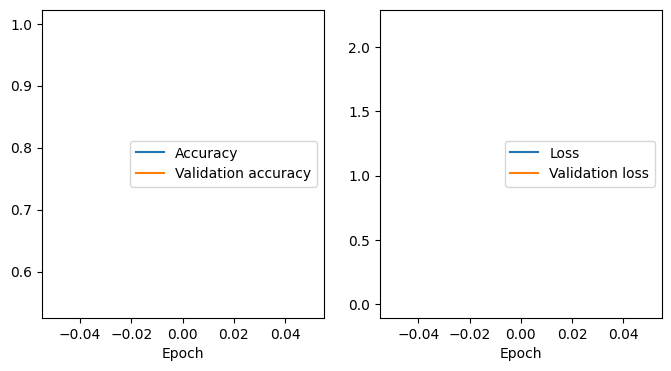

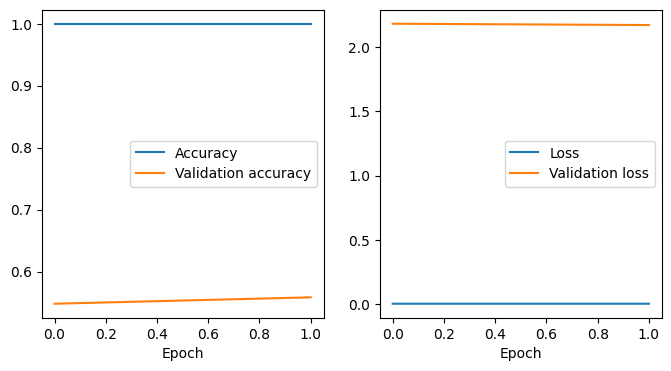

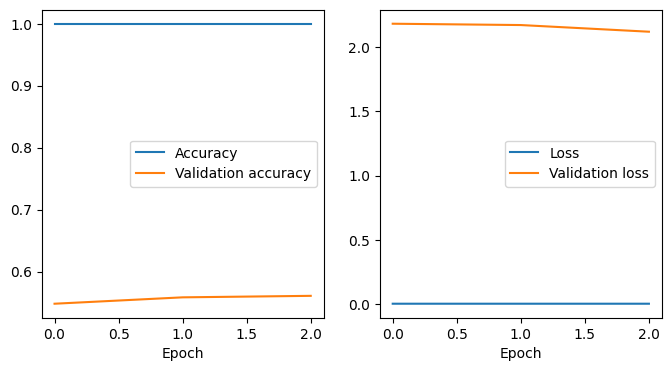

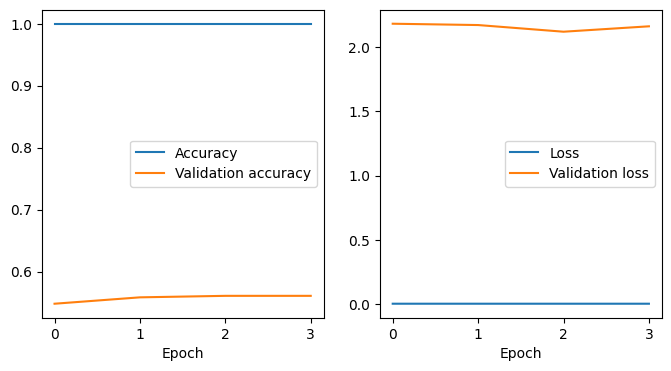

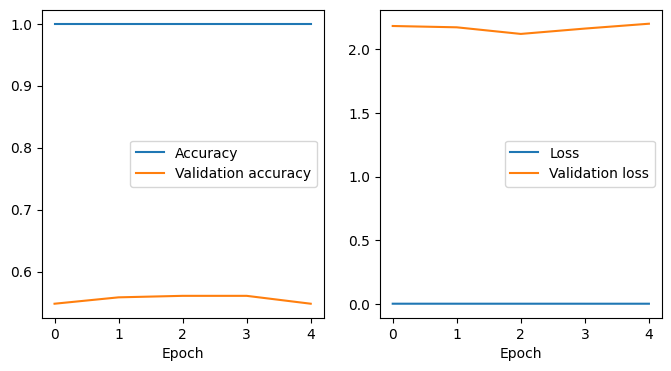

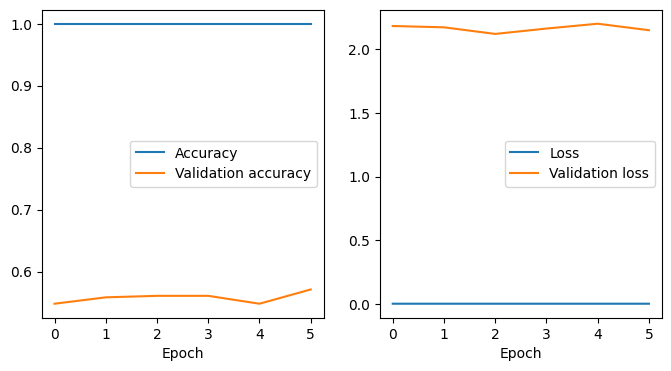

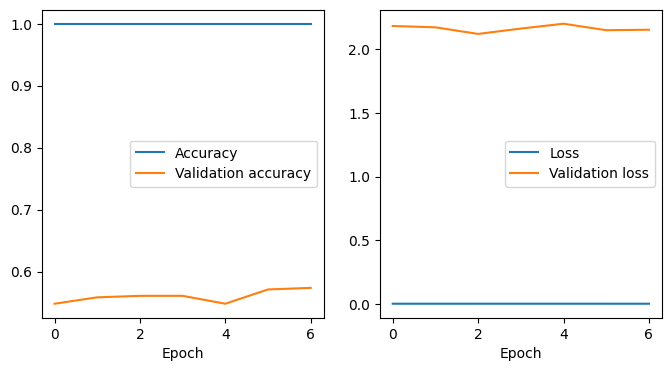

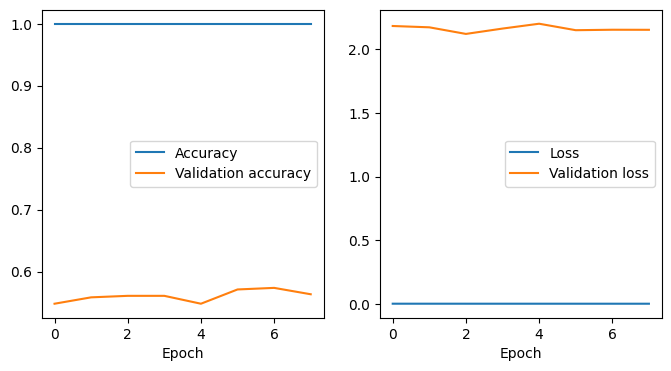

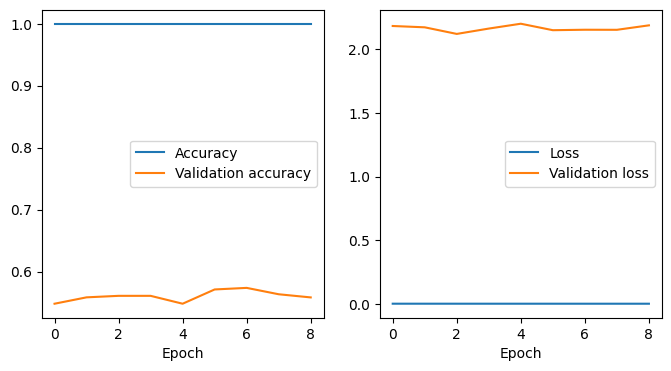

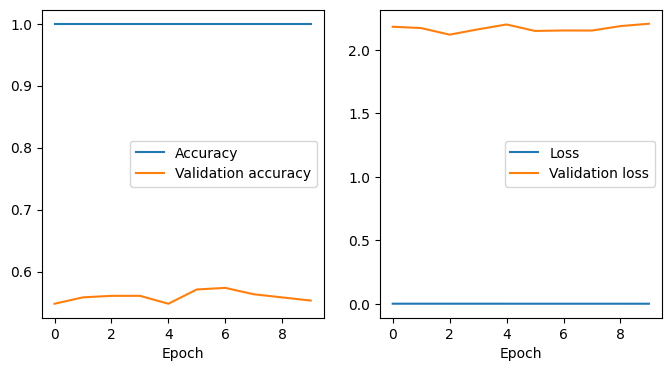

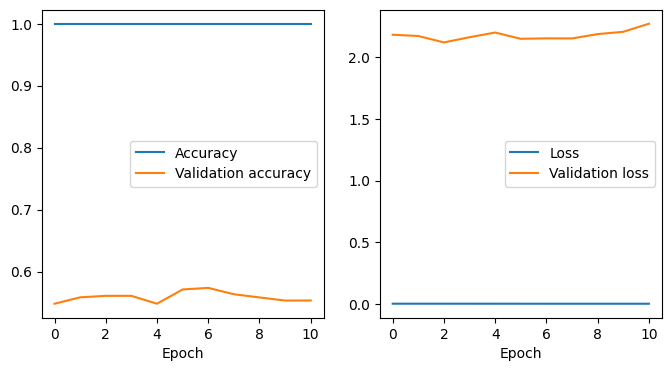

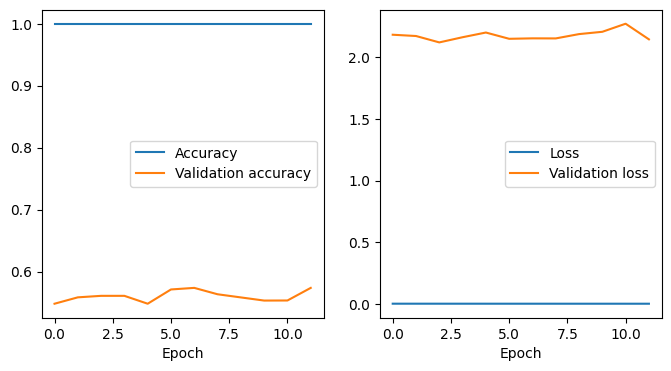

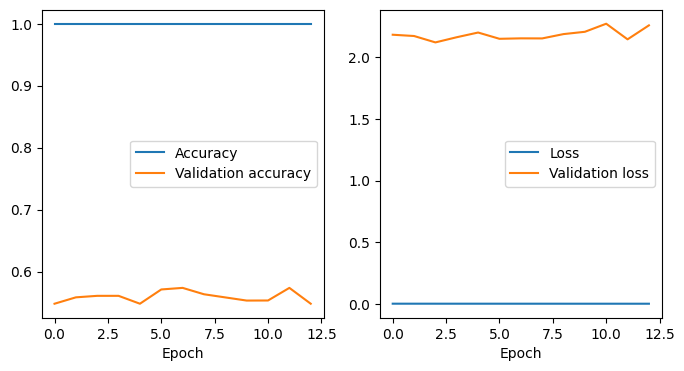

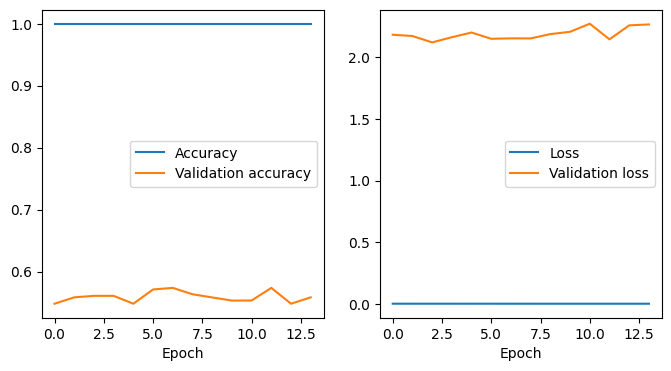

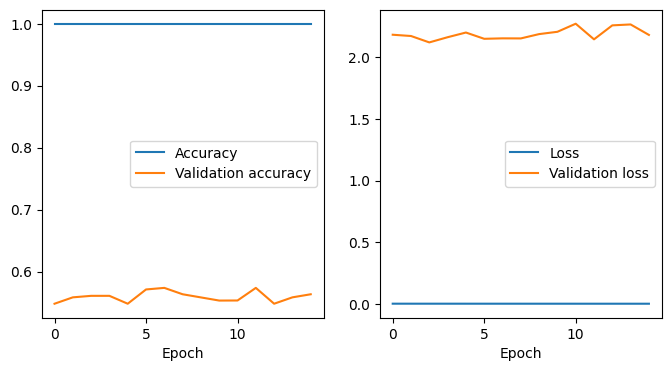

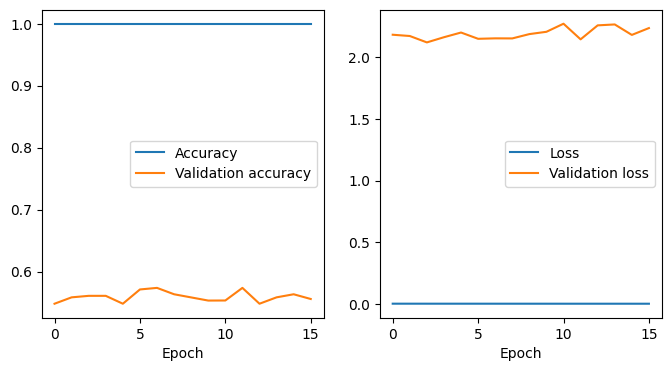

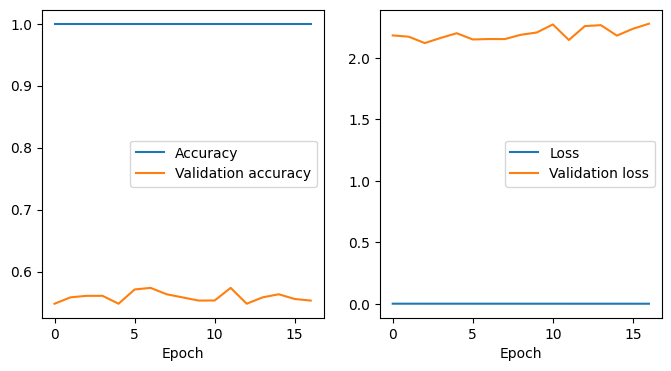

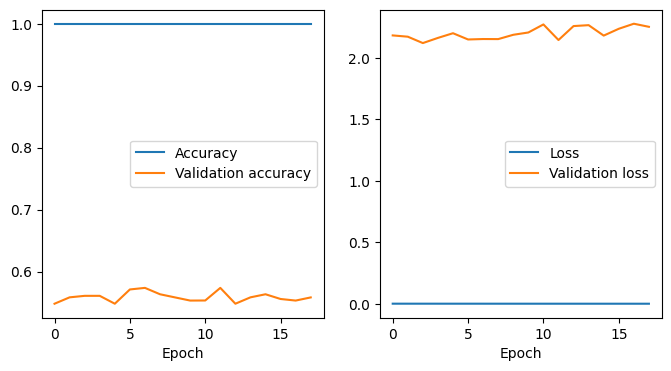

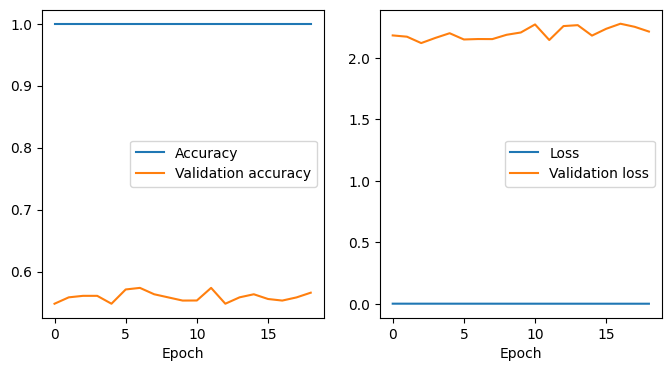

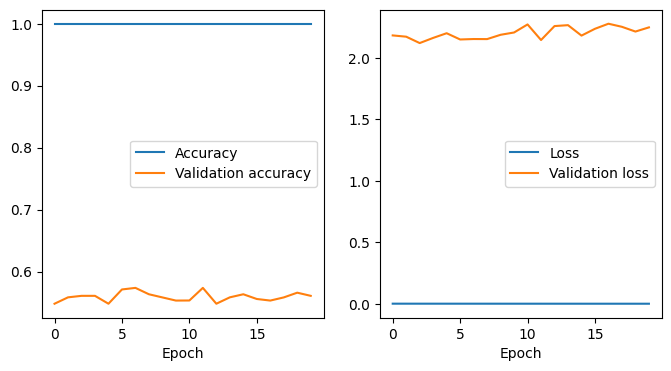

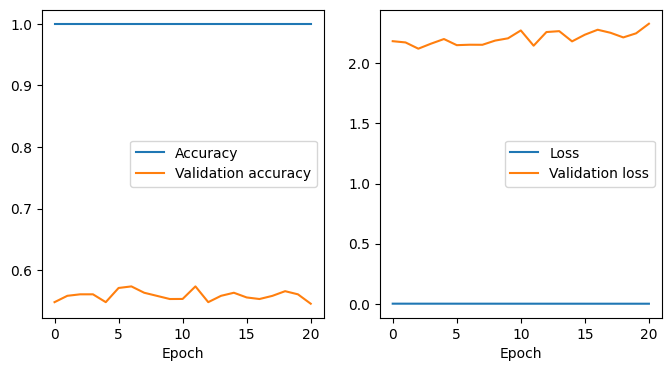

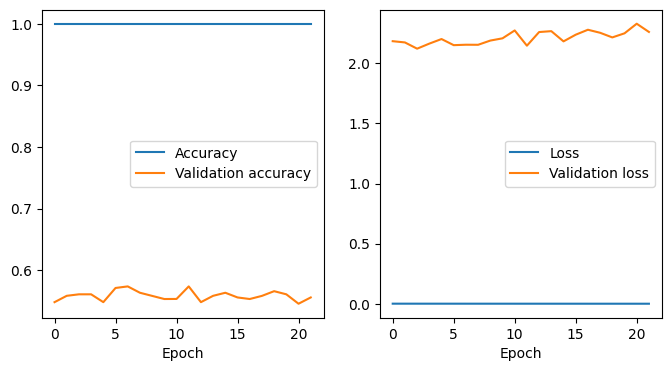

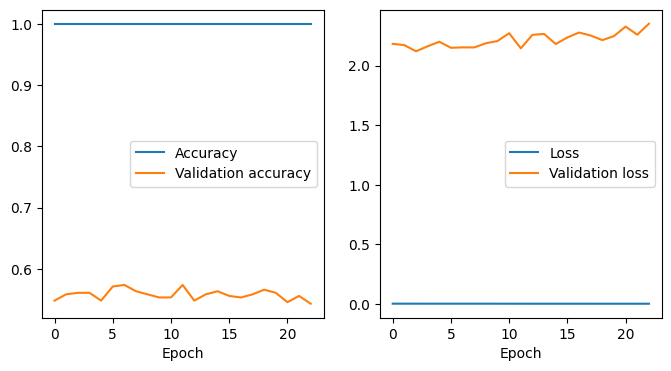

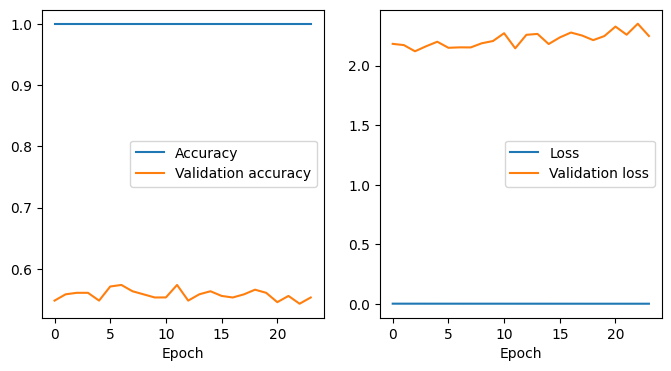

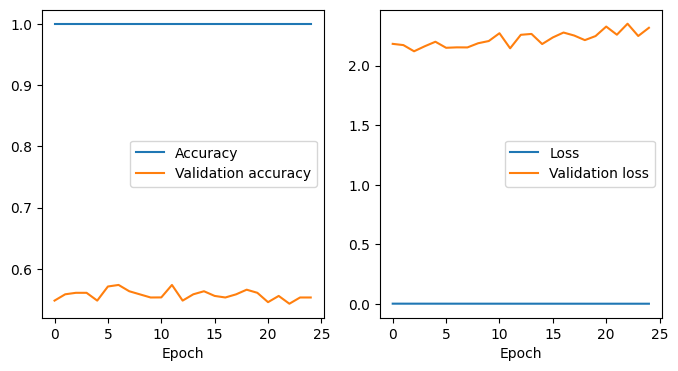

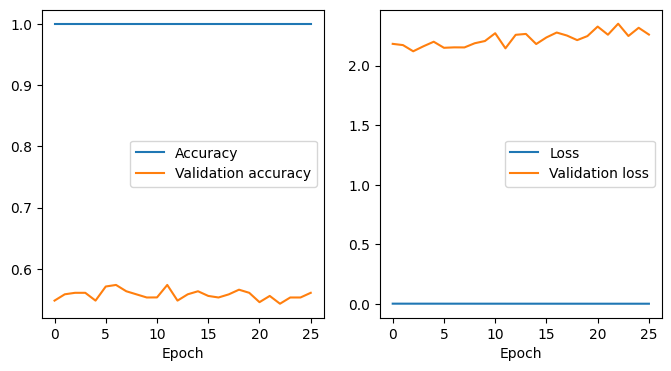

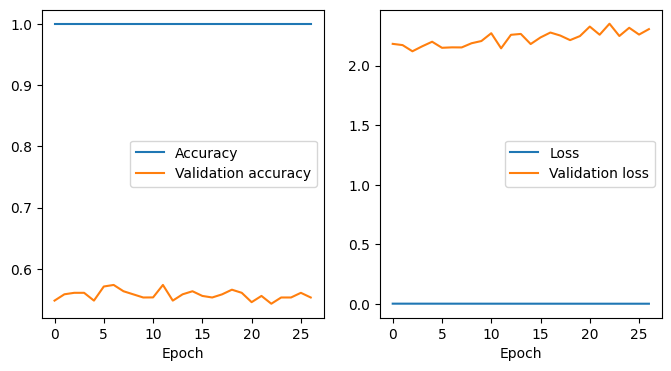

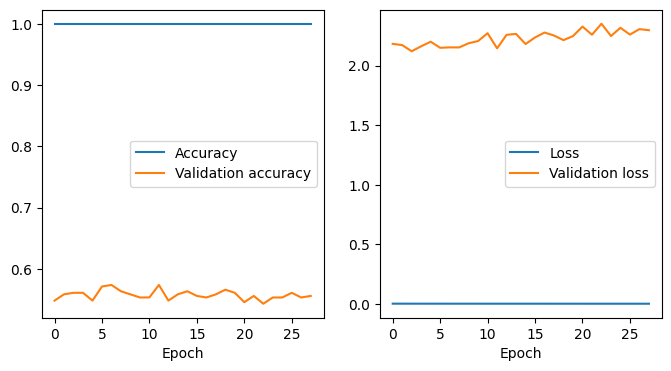

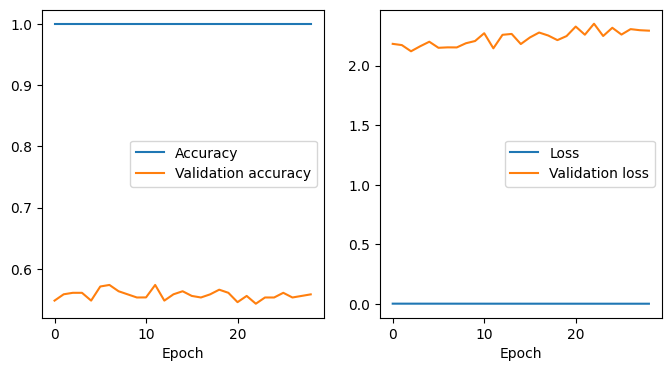

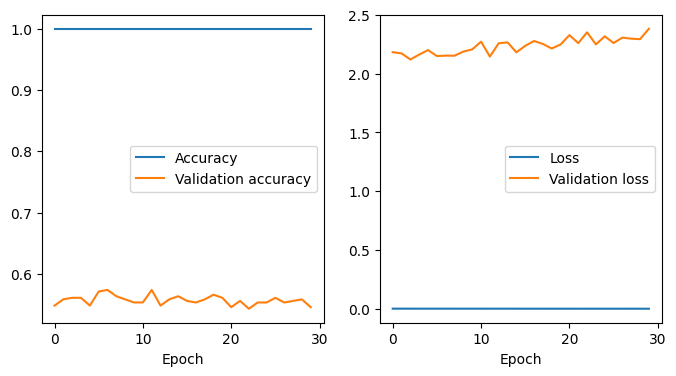

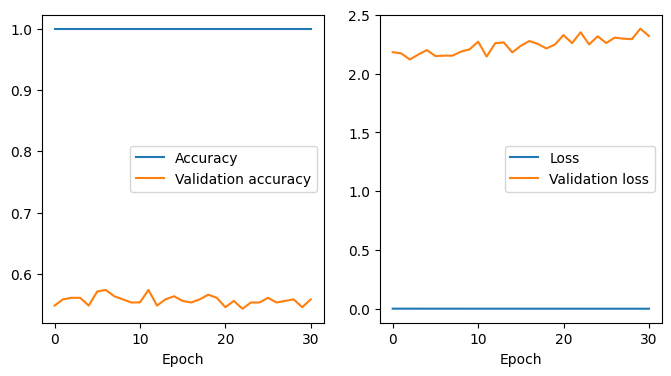

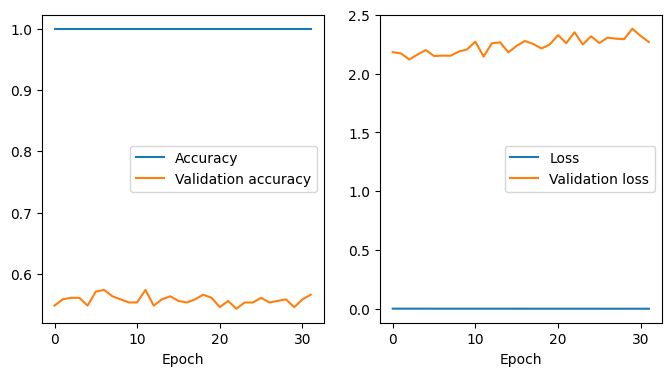

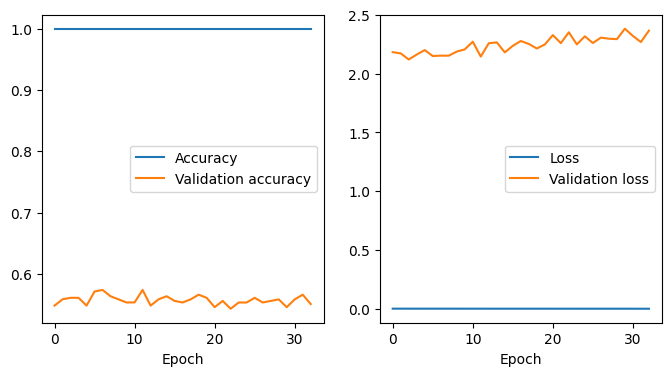

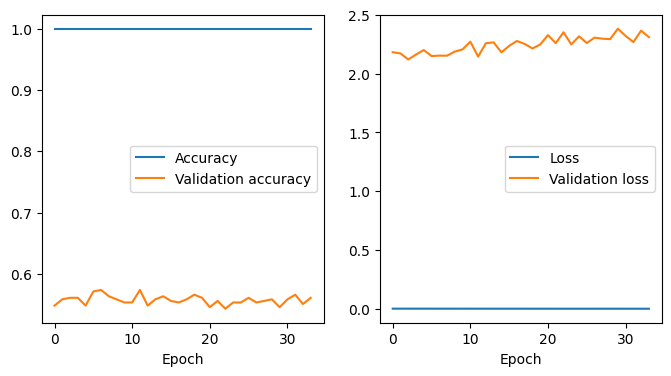

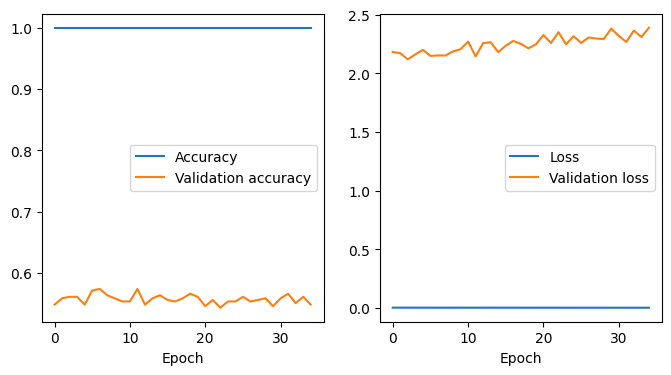

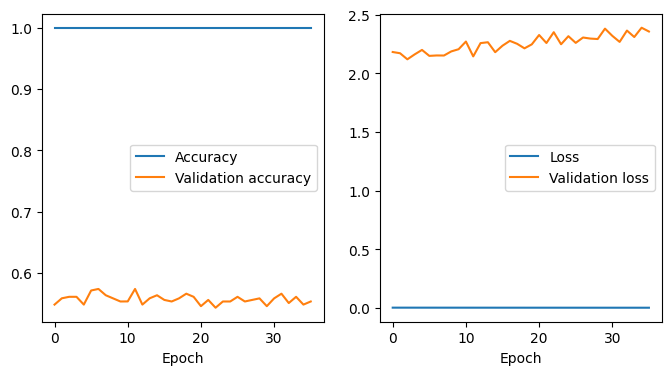

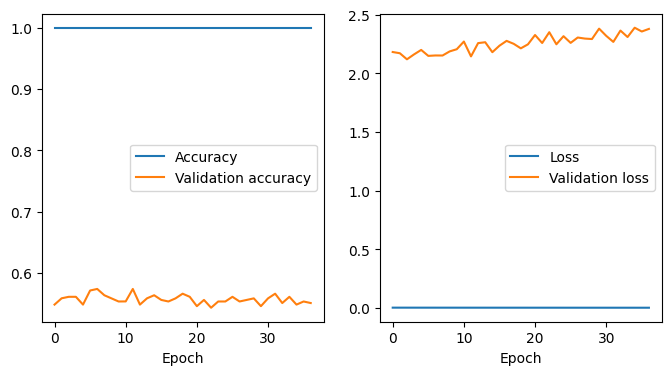

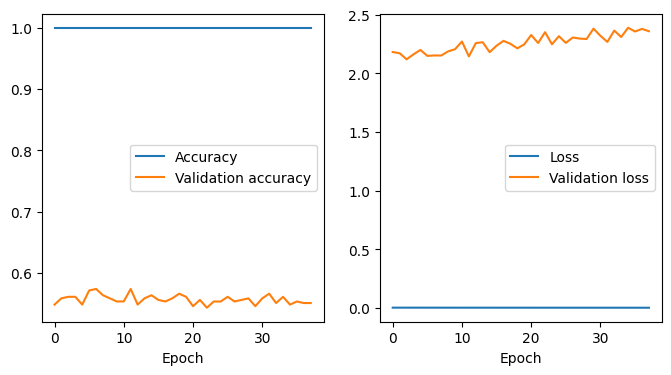

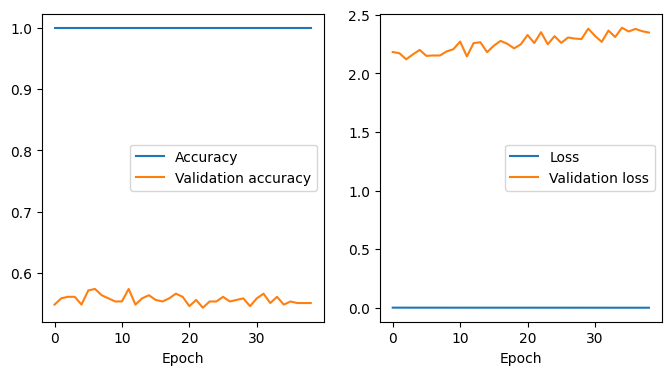

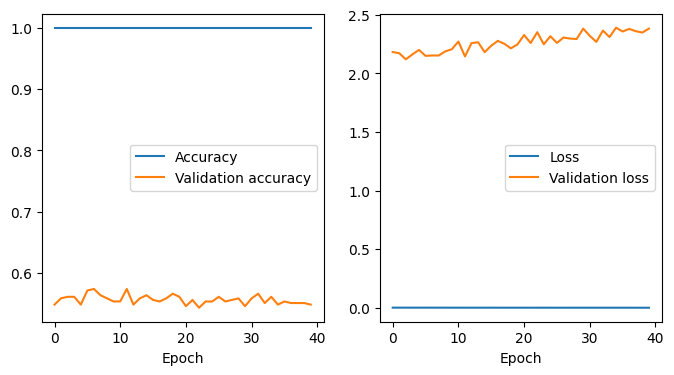

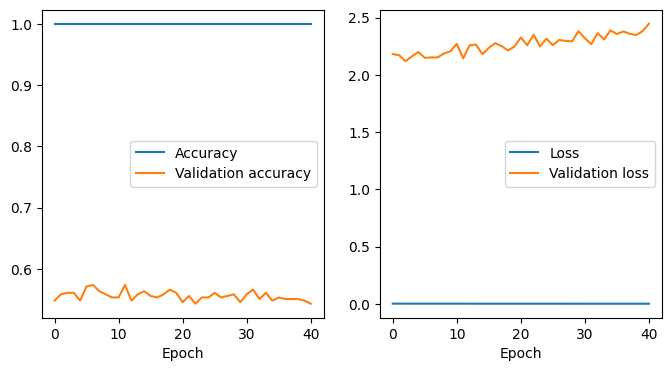

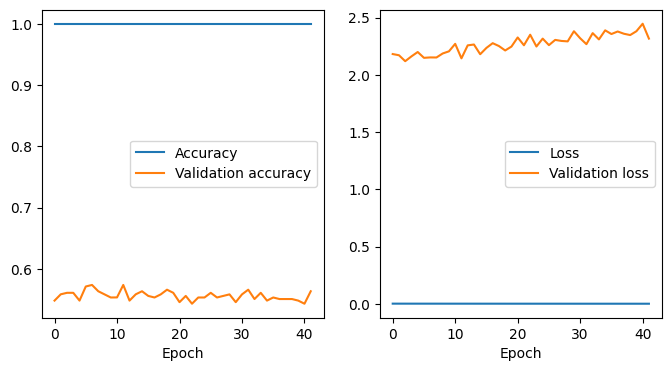

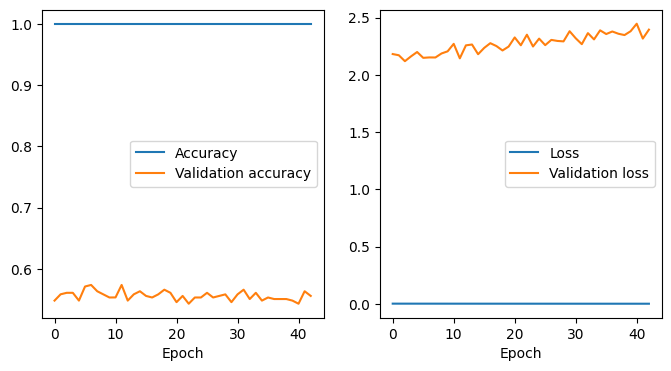

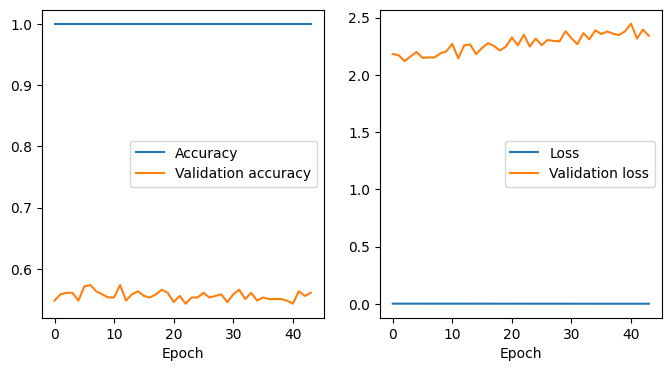

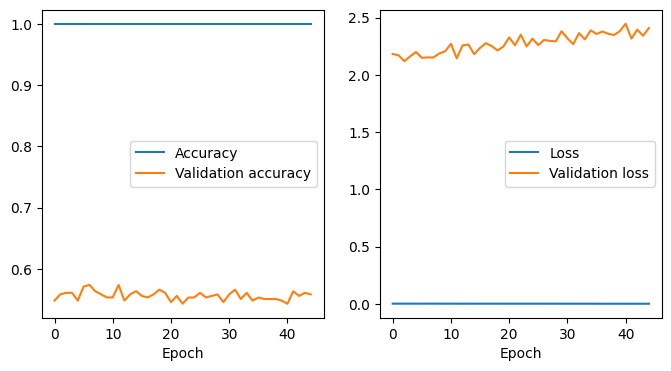

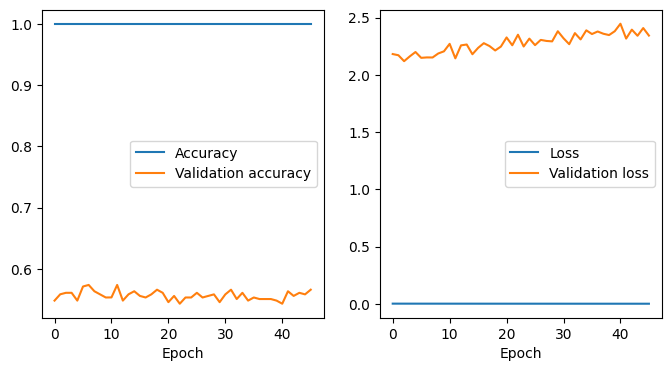

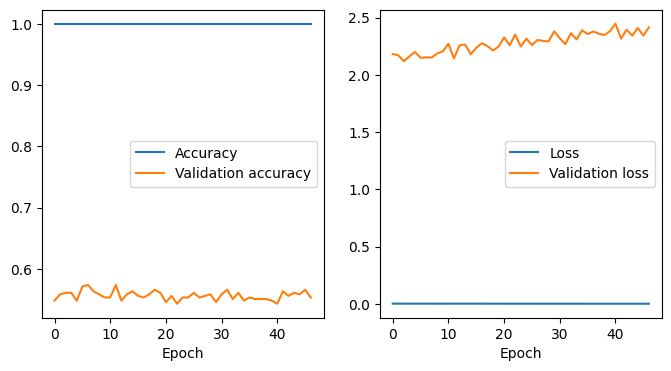

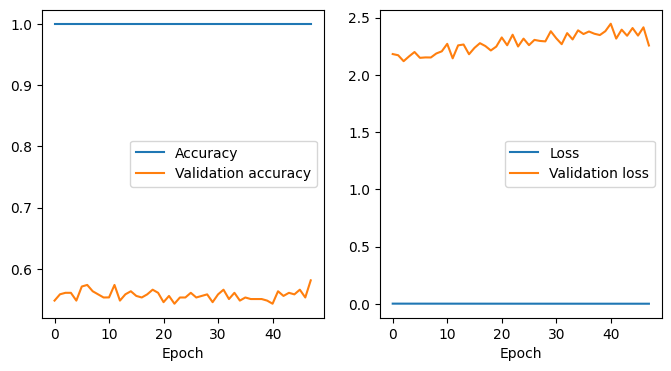

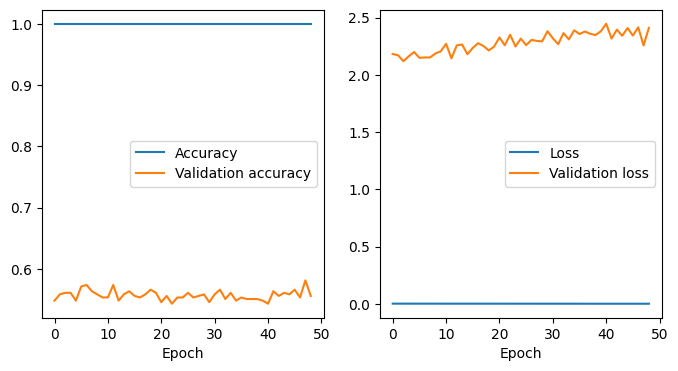

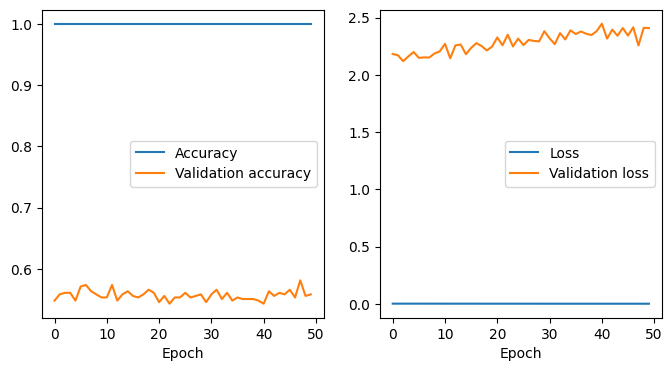

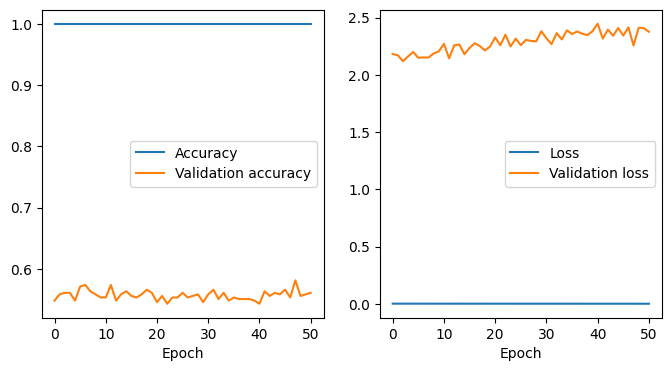

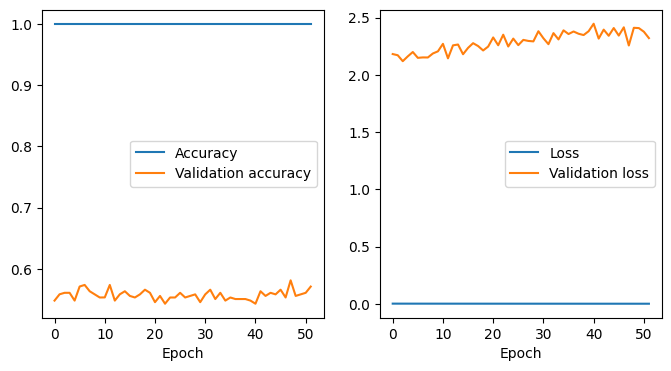

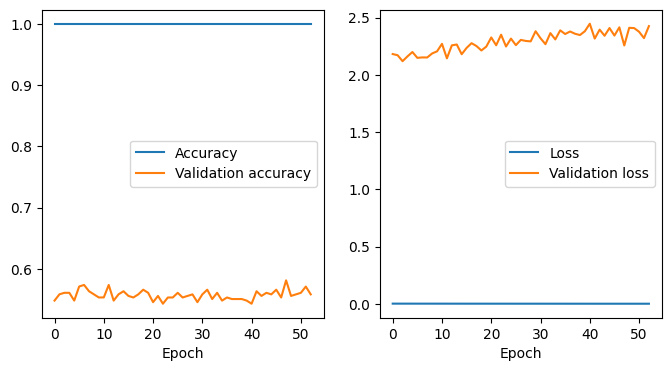

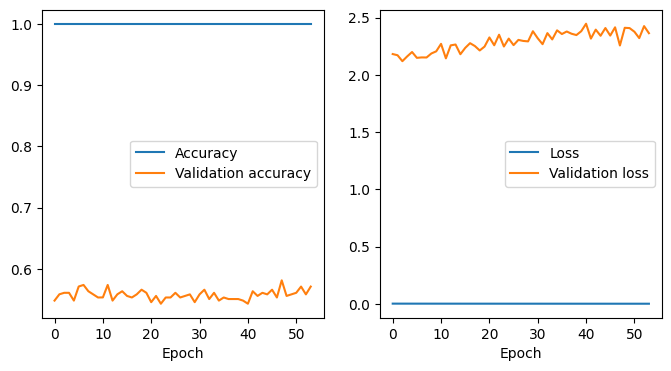

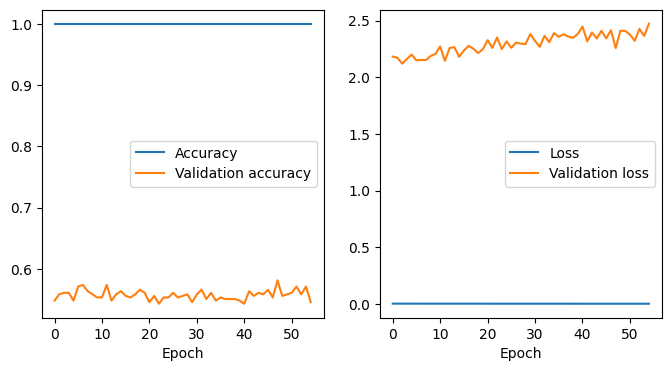

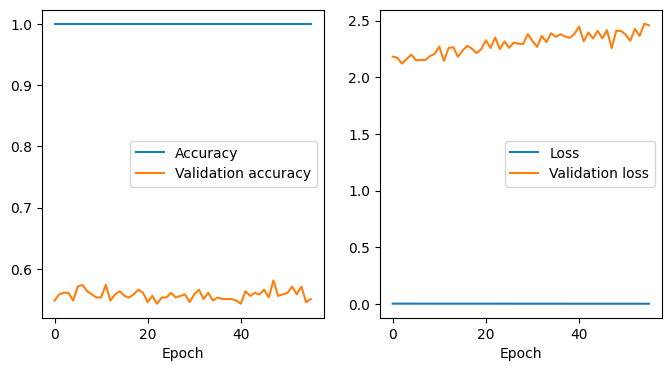

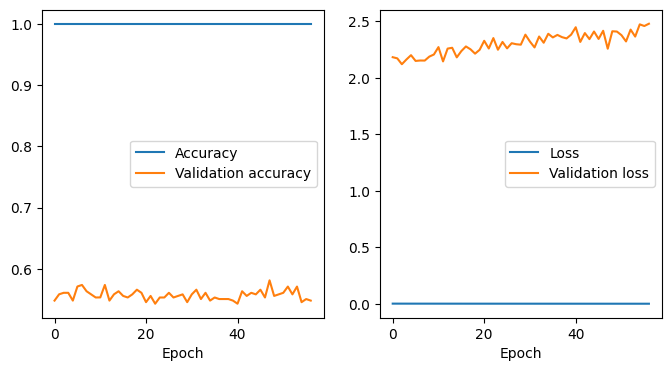

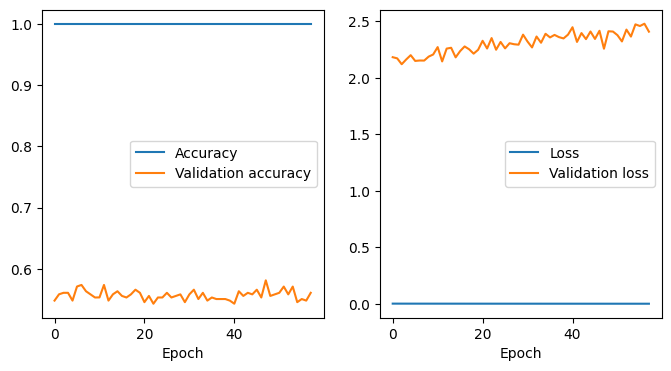

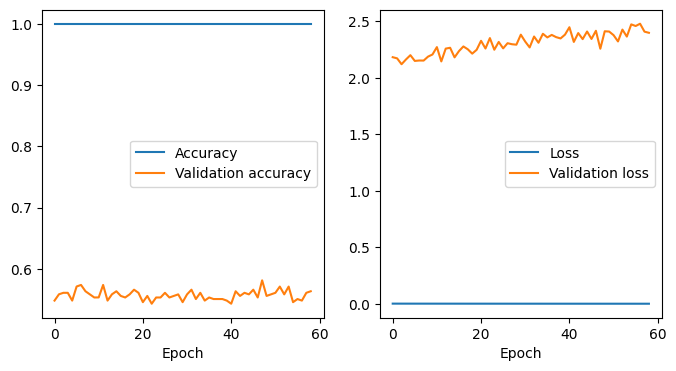

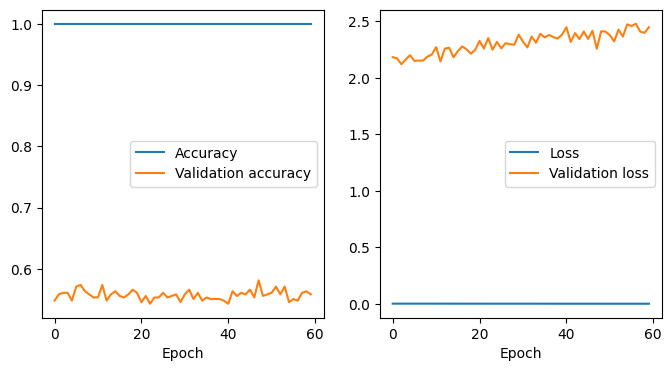

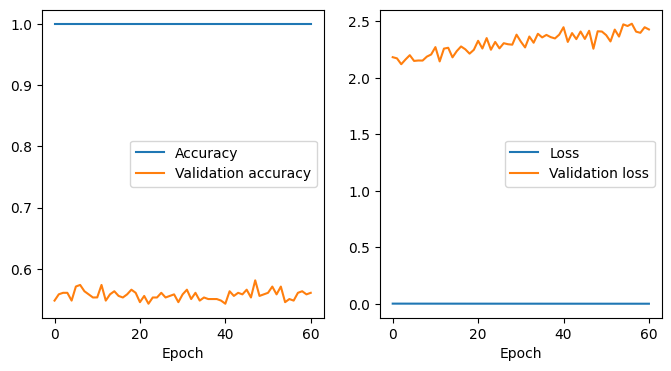

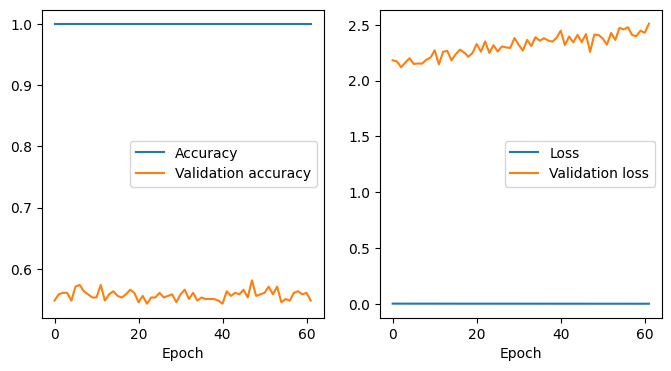

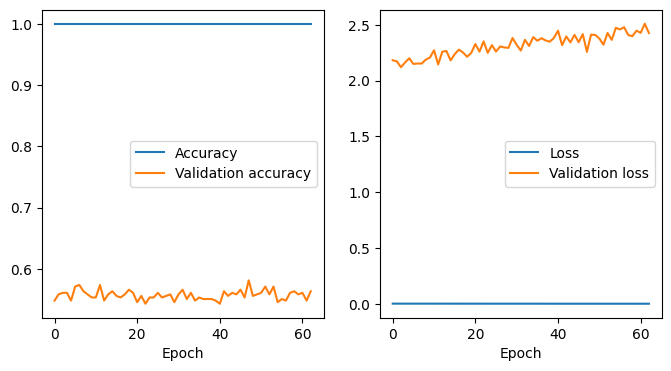

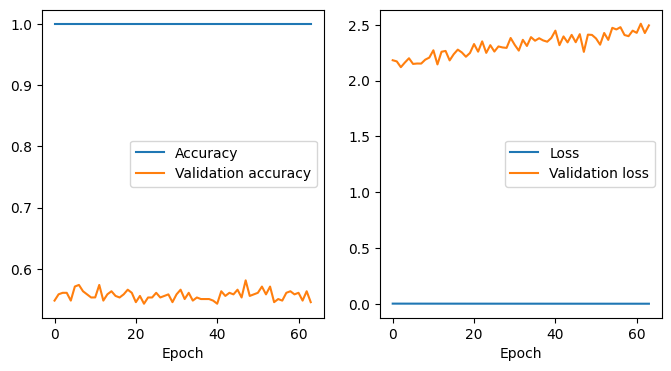

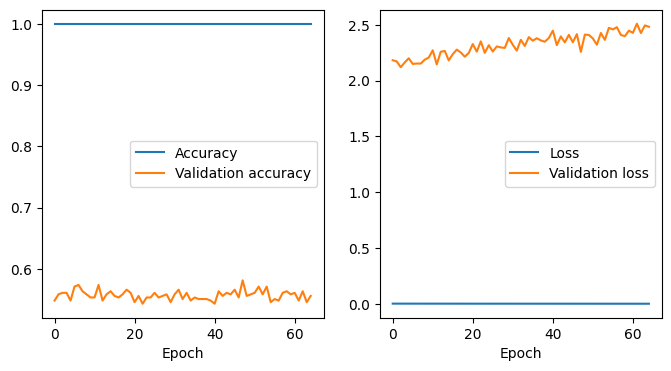

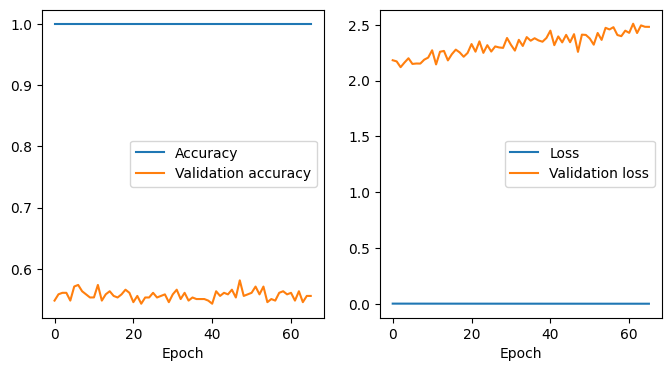

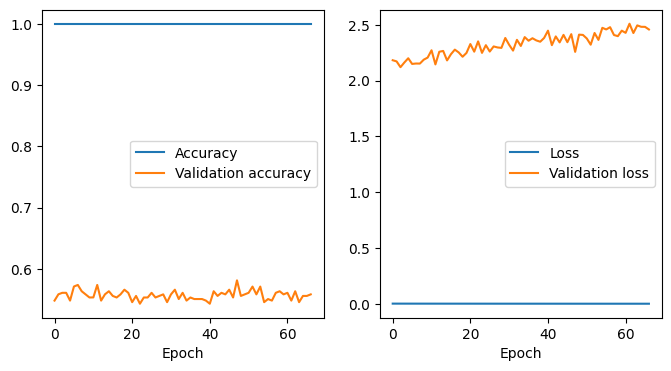

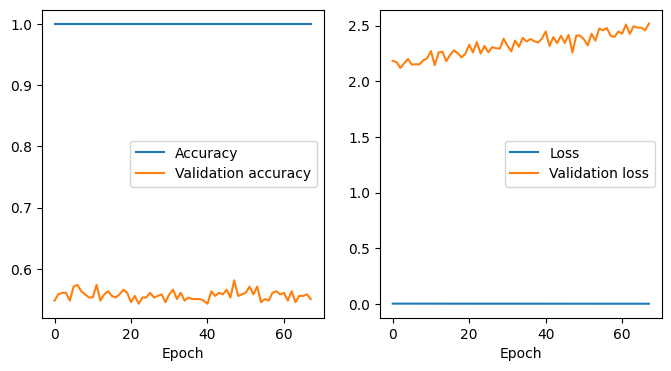

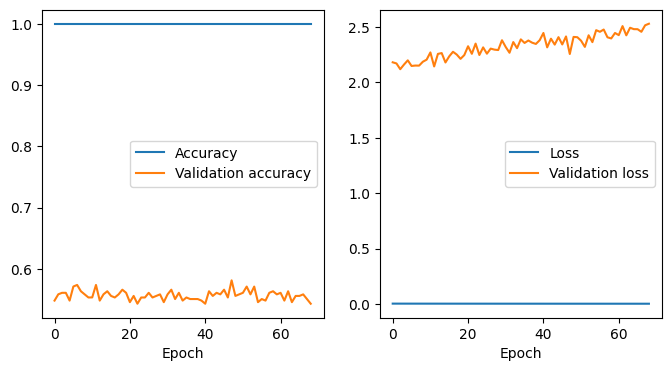

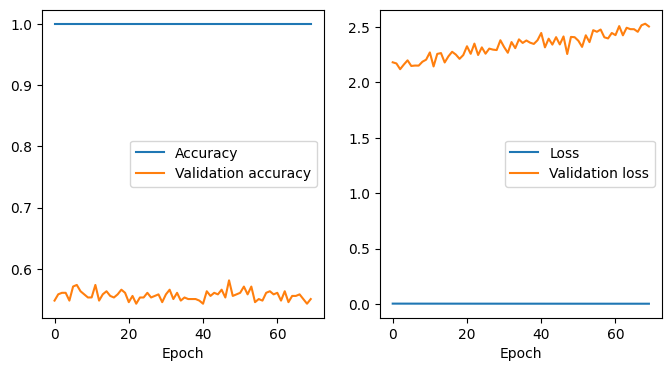

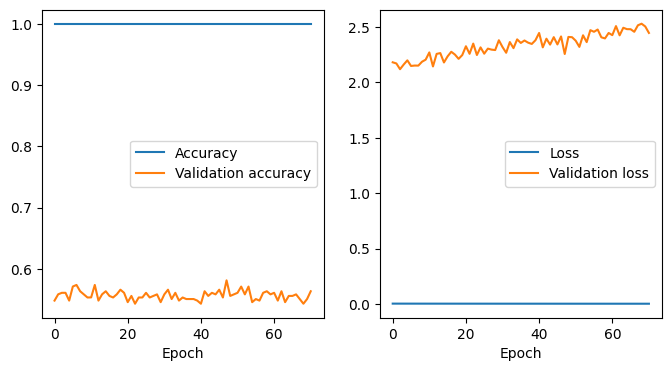

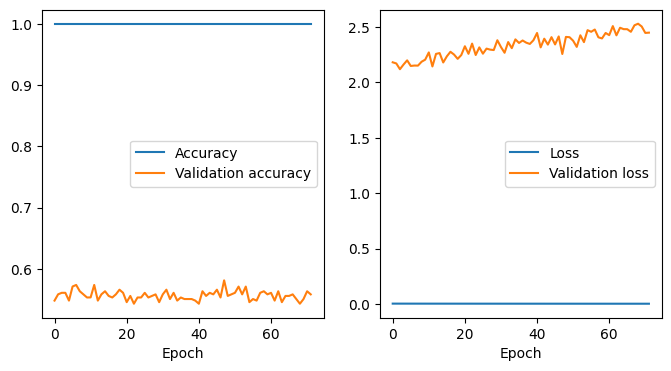

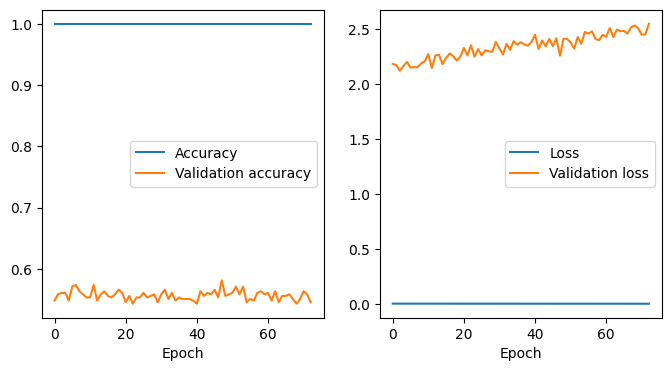

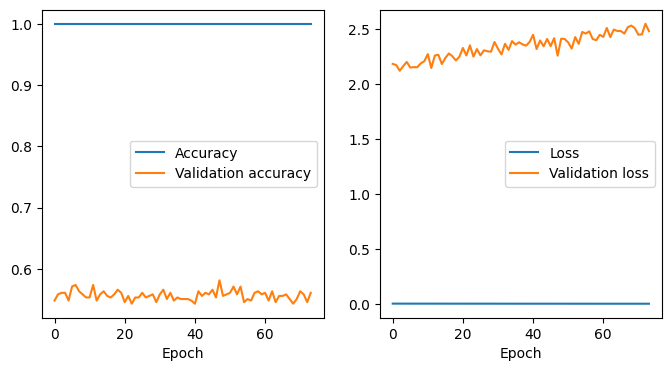

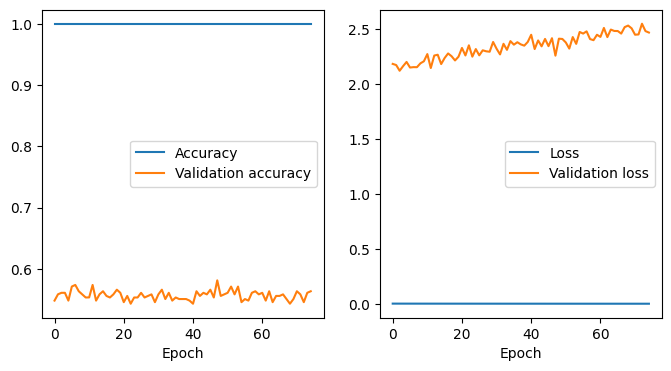

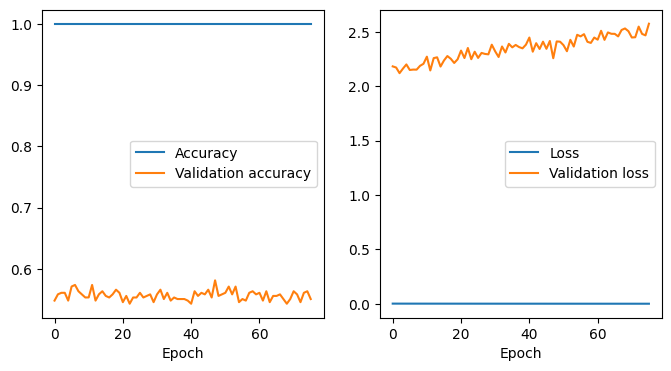

In [37]:
epoch_acc_l = []
epoch_loss_l = []
epoch_val_acc_l = []
epoch_val_loss_l = []



for epoch in range(epochs):
    epoch_loss = 0
    epoch_accuracy = 0

    for data, label in tqdm(train_loader):
        data = data.to(device)
        label = label.to(device)
        # label = label.unsqueeze(dim=1)


        output = model(data)
        output = output.squeeze()
        # print(output.shape)
        # print(output.dtype)

        loss = criterion(output, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        output = (output>0.5).type(torch.float32)

        # acc = (output.argmax(dim=1) == label).float().mean()
        acc = (output == label).float().mean()
        epoch_accuracy += acc / len(train_loader)
        epoch_loss += loss / len(train_loader)

    with torch.no_grad():
        epoch_val_accuracy = 0
        epoch_val_loss = 0
        for data, label in test_loader:
            data = data.to(device)
            label = label.to(device)
            # label = label.unsqueeze(dim=1)

            val_output = model(data)
            val_output = val_output.squeeze()

            print(val_output)


            val_loss = criterion(val_output, label)
            val_output = (val_output > 0.5).type(torch.float32)

            acc = (val_output == label).float().mean()
            # acc = (val_output.argmax(dim=1) == label).float().mean()
            epoch_val_accuracy += acc / len(test_loader)
            epoch_val_loss += val_loss / len(test_loader)

    epoch_acc_l += [float(epoch_accuracy)]
    epoch_loss_l += [float(epoch_loss)]
    epoch_val_loss_l += [float(epoch_val_loss)]
    epoch_val_acc_l += [float(epoch_val_accuracy)]

    training_stats = pd.DataFrame({"Accuracy":epoch_acc_l, "Loss":epoch_loss_l, "Val Accuracy":epoch_val_acc_l, "Val Loss":epoch_val_loss_l})

    makeAccGraph(training_stats)
    print(
        f"Epoch : {epoch+1} - loss : {epoch_loss:.4f} - acc: {epoch_accuracy:.4f} - val_loss : {epoch_val_loss:.4f} - val_acc: {epoch_val_accuracy:.4f}\n"
    )
